C:\Users\rajay\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9175 - loss: 0.4150 - val_accuracy: 0.9423 - val_loss: 0.2231
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9342 - loss: 0.2442 - val_accuracy: 0.9423 - val_loss: 0.2237
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9398 - loss: 0.2293 - val_accuracy: 0.9423 - val_loss: 0.2211
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9347 - loss: 0.2415 - val_accuracy: 0.9423 - val_loss: 0.2209
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9380 - loss: 0.2305 - val_accuracy: 0.9423 - val_loss: 0.2244
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9251 - loss: 0.2706 - val_accuracy: 0.9423 - val_loss: 0.2200
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9412 - loss: 0.2225 - val_accuracy: 0.9423 - val_loss: 0.2238
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9400 - loss: 0.2262 - val_accuracy: 0.9423 - va

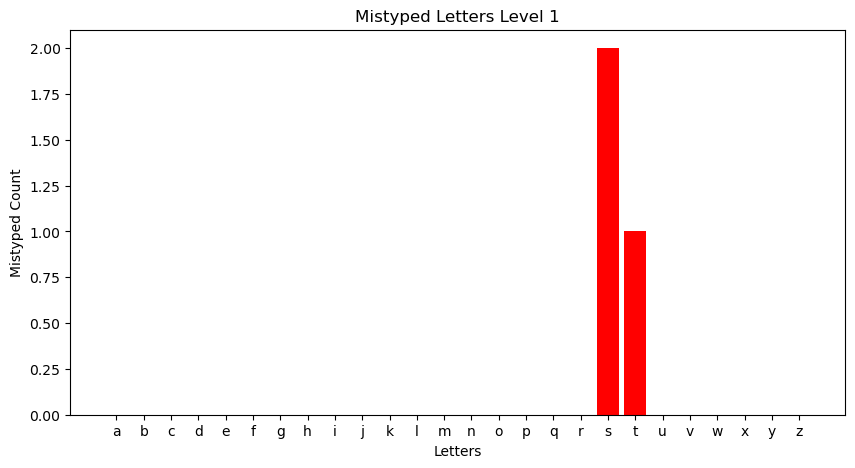

Use the following fingers to type 'history':
  H: right index finger
  I: right middle finger
  S: left ring finger
  T: left index finger
  O: right ring finger
  R: left index finger
  Y: right index finger
Type the following word: history
history
Use the following fingers to type 'various':
  V: left index finger
  A: left pinky
  R: left index finger
  I: right middle finger
  O: right ring finger
  U: right index finger
  S: left ring finger
Type the following word: various
various
Use the following fingers to type 'institution':
  I: right middle finger
  N: right index finger
  S: left ring finger
  T: left index finger
  I: right middle finger
  T: left index finger
  U: right index finger
  T: left index finger
  I: right middle finger
  O: right ring finger
  N: right index finger
Type the following word: institution
instituiton
Use the following fingers to type 'just':
  J: right index finger
  U: right index finger
  S: left ring finger
  T: left index finger
Type the follo

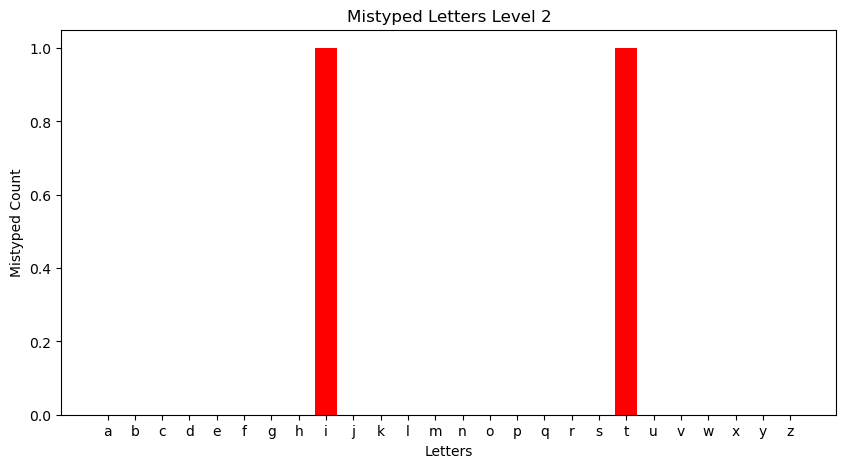

Type the following sentence: the view from here is beautiful
the view i
Type the following sentence: the kitchen is newly renovated
ahaj
Type the following sentence: lions kill for food
jjss
Type the following sentence: she tends to be quiet
kaka
Type the following sentence: please describe the situation clearly
ajaj
Typing accuracy for level 3: 0.0%


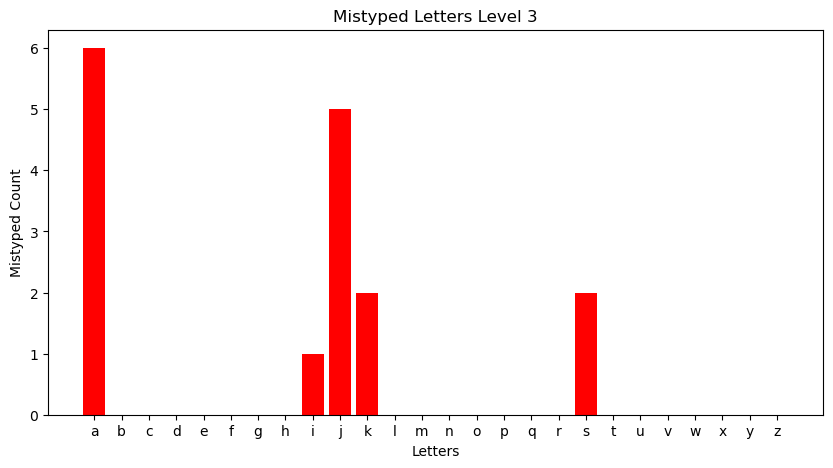

Type the following sentence: she had a difficult choice to make
ahaa
Type the following sentence: the victim was unharmed
anana
Type the following sentence: the institution is well-regarded
aaj
Type the following sentence: once upon a time
aa
Type the following sentence: the man walked his dog
aa
Typing accuracy for level 4: 0.0%


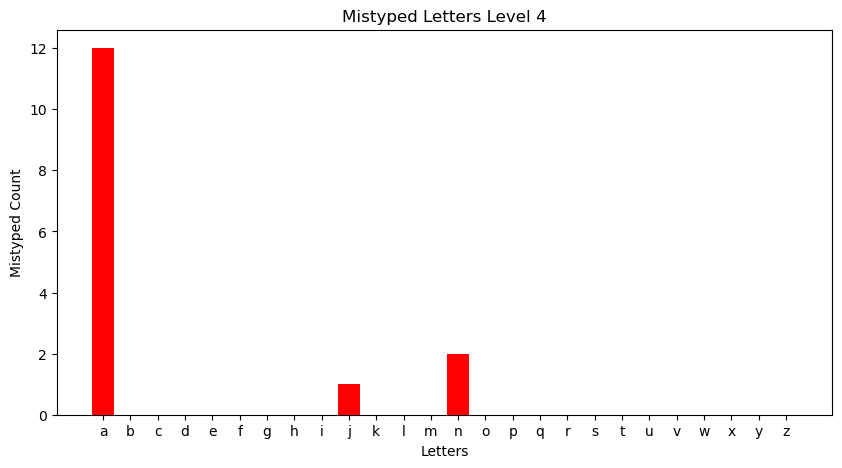

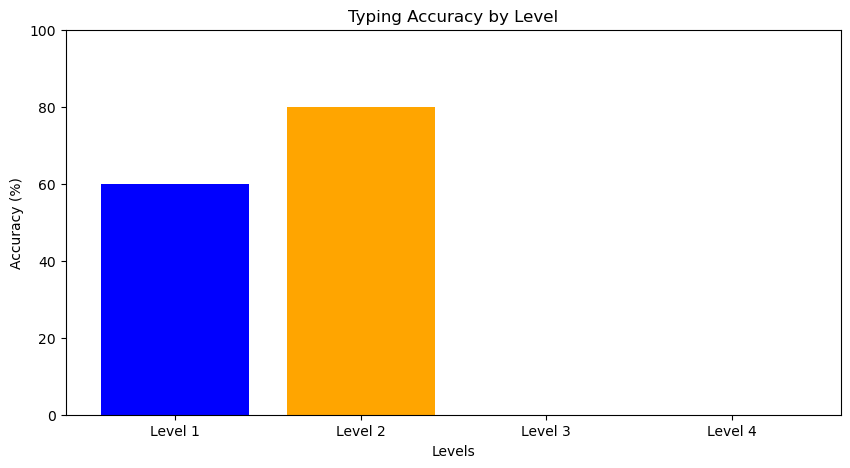

Overall typing accuracy: 35.0%


In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Function to load words and sentences from a CSV file
def load_data_from_csv(filename):
    df = pd.read_csv(filename)
    words = df['Words'].tolist()
    sentences = df['Sentences'].tolist()
    return words, sentences

# Initialize mistyped words list and accuracy tracking
mistyped_words = []
accuracies = []
mistyped_letters_by_level = {1: [], 2: [], 3: [], 4: []}

# Finger mapping according to the universal format
finger_mapping = {
    '1': 'left pinky', '2': 'left ring finger', '3': 'left middle finger', '4': 'left index finger',
    '5': 'left index finger', '6': 'right index finger', '7': 'right index finger', '8': 'right middle finger',
    '9': 'right ring finger', '0': 'right pinky', '-': 'right pinky', '=': 'right pinky',
    'q': 'left pinky', 'w': 'left ring finger', 'e': 'left middle finger', 'r': 'left index finger',
    't': 'left index finger', 'y': 'right index finger', 'u': 'right index finger', 'i': 'right middle finger',
    'o': 'right ring finger', 'p': 'right pinky', '[': 'right pinky', ']': 'right pinky', '\\': 'right pinky',
    'a': 'left pinky', 's': 'left ring finger', 'd': 'left middle finger', 'f': 'left index finger',
    'g': 'left index finger', 'h': 'right index finger', 'j': 'right index finger', 'k': 'right middle finger',
    'l': 'right ring finger', ';': 'right pinky', "'": 'right pinky',
    'z': 'left pinky', 'x': 'left ring finger', 'c': 'left middle finger', 'v': 'left index finger',
    'b': 'left index finger', 'n': 'right index finger', 'm': 'right index finger', ',': 'right middle finger',
    '.': 'right ring finger', '/': 'right pinky', ' ': 'thumbs'
}

# Function to display finger instructions for typing a word
def display_finger_instructions(word):
    instructions = [finger_mapping.get(char, 'unknown') for char in word]
    print(f"Use the following fingers to type '{word}':")
    for char, instruction in zip(word, instructions):
        print(f"  {char.upper()}: {instruction}")

# Load and preprocess the comprehensive typing accuracy dataset
df = pd.read_csv("lstm_model_train_dataset.csv")
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(df['Word'])
sequences = tokenizer.texts_to_sequences(df['Word'])
max_len = max(len(seq) for seq in sequences)
X = pad_sequences(sequences, maxlen=max_len)
y = df['Correct'].values

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the LSTM model
model = Sequential()
model.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32, input_length=max_len))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, validation_split=0.2)
model.save('typing_accuracy_model.keras')

# Function to predict typing accuracy using the LSTM model
def predict_typing_accuracy(typed_item):
    sequence = tokenizer.texts_to_sequences([typed_item])
    padded_sequence = pad_sequences(sequence, maxlen=max_len)
    prediction = model.predict(padded_sequence)
    return prediction[0][0]

# Function to collect mistyped letters
def collect_mistyped_letters(typed, original, level):
    for char_typed, char_original in zip(typed, original):
        if char_typed != char_original:
            mistyped_letters_by_level[level].append(char_typed)

# Visualize mistyped letters function
def visualize_mistyped_letters(level):
    letter_counts = Counter(mistyped_letters_by_level[level])
    all_letters = [chr(i) for i in range(97, 123)]
    counts = [letter_counts.get(letter, 0) for letter in all_letters]
    plt.figure(figsize=(10, 5))
    plt.bar(all_letters, counts, color='red')
    plt.xlabel('Letters')
    plt.ylabel('Mistyped Count')
    plt.title(f'Mistyped Letters Level {level}')
    plt.show()

# Function to find items with most mistyped letters from the previous level
def get_items_with_most_mistyped_letters(items, mistyped_letters, level):
    if level > 1 and mistyped_letters:
        most_mistyped_letter = Counter(mistyped_letters).most_common(1)[0][0]
        items_with_most_mistyped = [item for item in items if most_mistyped_letter in item]
        return items_with_most_mistyped
    return items

# Typing test function for words
def typing_test_words(items, level=1):
    if level > 1:
        items = get_items_with_most_mistyped_letters(items, mistyped_letters_by_level[level - 1], level)
    sampled_items = random.sample(items, min(5, len(items)))
    correct_count = 0
    for item in sampled_items:
        display_finger_instructions(item)
        print(f'Type the following word: {item}')
        typed_item = input().lower()
        if typed_item == item:
            correct_count += 1
        else:
            mistyped_words.append(typed_item)
            collect_mistyped_letters(typed_item, item, level)
    typing_accuracy = correct_count / len(sampled_items) * 100
    accuracies.append(typing_accuracy)
    print(f"Typing accuracy for level {level}: {typing_accuracy}%")
    return typing_accuracy

# Typing test function for sentences
def typing_test_sentences(items, level):
    if level > 1:
        items = get_items_with_most_mistyped_letters(items, mistyped_letters_by_level[level - 1], level)
    sampled_items = random.sample(items, min(5, len(items)))
    correct_count = 0
    for item in sampled_items:
        print(f'Type the following sentence: {item}')
        typed_item = input().lower()
        if typed_item == item:
            correct_count += 1
        else:
            collect_mistyped_letters(typed_item, item, level)
    typing_accuracy = correct_count / len(sampled_items) * 100
    accuracies.append(typing_accuracy)
    print(f"Typing accuracy for level {level}: {typing_accuracy}%")
    return typing_accuracy

# Main function
def main():
    # Load words and sentences from the CSV file
    words, sentences = load_data_from_csv("words_sentences_meaningful - words_sentences_meaningful.csv.csv")

    # Level 1: Typing test with words
    typing_test_words(words, level=1)
    visualize_mistyped_letters(level=1)

    # Level 2: Typing test with words including the most mistyped letter from Level 1
    typing_test_words(words, level=2)
    visualize_mistyped_letters(level=2)

    # Level 3: Typing test with sentences
    typing_test_sentences(sentences, level=3)
    visualize_mistyped_letters(level=3)

    # Level 4: Typing test with sentences including the most mistyped letter from Level 3
    typing_test_sentences(sentences, level=4)
    visualize_mistyped_letters(level=4)

    # Visualize typing accuracy across all levels
    plt.figure(figsize=(10, 5))
    plt.bar(['Level 1', 'Level 2', 'Level 3', 'Level 4'], accuracies, color=['blue', 'orange', 'green', 'purple'])
    plt.xlabel('Levels')
    plt.ylabel('Accuracy (%)')
    plt.title('Typing Accuracy by Level')
    plt.ylim(0, 100)
    plt.show()

    # Calculate overall accuracy
    overall_accuracy = sum(accuracies) / len(accuracies)
    print(f"Overall typing accuracy: {overall_accuracy}%")

if __name__ == '__main__':
    main()
